In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable
import torchvision
import torchvision.utils as utils
import torchvision.datasets as dsets
import torchvision.transforms as transforms


In [2]:
import random

# Set random seed for reproducibility
manualSeed = 2020
#manualSeed = random.randint(1, 10000) # use if you want new results
print("Random Seed: ", manualSeed)
random.seed(manualSeed)
torch.manual_seed(manualSeed)

Random Seed:  2020


In [3]:
is_cuda = torch.cuda.is_available()
device = torch.device('cuda' if is_cuda else 'cpu')

print(device)


cuda


In [4]:
# hyper-parameter
batch_size = 64

In [5]:
# standardizer
standardizer = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=0,
                         std=1)])


In [6]:
# MNIST dataset
train_data = dsets.MNIST(root='../data/', train=True, transform=standardizer, download=True)

In [7]:
train_data_loader = torch.utils.data.DataLoader(train_data, batch_size, shuffle=True)

In [8]:
# function for visualization
def tc_imshow(img, lbl=""):
    if img.size(0) == 1:
        plt.imshow(img.squeeze(), cmap='gray')
    else:
        plt.imshow(np.transpose(img, (1, 2, 0)))

    plt.title(lbl)
    plt.axis('off')


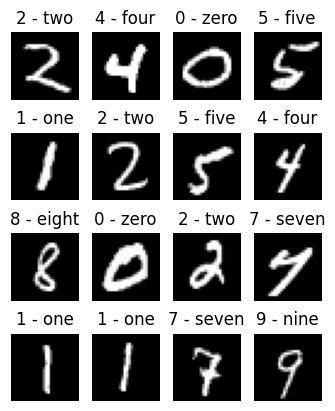

In [10]:
from genericpath import exists
# visualize
mini_batch_img, mini_batch_lbl = next(iter(train_data_loader))

plt.figure(figsize=(4,5))
for i in range(16):
    plt.subplot(4,4,i+1)
    tc_imshow(img=mini_batch_img[i],
              lbl=train_data.classes[mini_batch_lbl[i].numpy()])
    plt.axis('off')


os.makedirs("./result/GAN/1-GAN", exist_ok=True)
plt.savefig('./result/GAN/1-GAN/1-dataloader-example.png', dpi=300)


In [11]:
# hyper-parameter
dim_noise = 100

In [12]:
# Random sampling from normal distribution
def random_sample_z_space(batch_size=1, dim_noise=100):
    return torch.randn(batch_size, dim_noise, device=device)

In [13]:
# hyper-paremeters
dim_hidden = 256
sz_output = 28
num_channels = 1

In [14]:
dim_output = sz_output**2
img_shape = (num_channels, sz_output, sz_output)

In [15]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
                    nn.Linear(dim_noise, dim_hidden),
                    nn.ReLU(),
                    nn.Dropout(0.1),
                    nn.Linear(dim_hidden, dim_hidden),
                    nn.ReLU(),
                    nn.Dropout(0.1),
                    nn.Linear(dim_hidden, dim_output),
                    nn.Tanh()
        )
    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), *img_shape)
        return img


In [16]:
G = Generator().to(device)
z = random_sample_z_space()

In [17]:
# visualize
utils.save_image(G(z)[:25].cpu().detach(), "./result/GAN/1-GAN/2-G(z).png", nrow=5, normalize=True)


In [18]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(dim_output, dim_hidden),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(dim_hidden, dim_hidden),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(dim_hidden, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        flat_img = img.view(img.size(0), -1)
        check_validity = self.model(flat_img)

        return check_validity


In [19]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

In [20]:
# hyper-parameter
learning_rate = 0.0002
beta1 = 0.9

In [21]:
adversarial_loss = nn.BCELoss()

In [22]:
optimizer_G = optim.Adam(generator.parameters(), lr=learning_rate, betas=(beta1, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=learning_rate, betas=(beta1, 0.999))

In [23]:
# hyper-parameters
num_epochs = 200
interval_save_img = 1000

In [24]:
Tensor = torch.cuda.FloatTensor if is_cuda else torch.FloatTensor

In [25]:
losses = []

for idx_epoch in range(num_epochs):
    for idx_batch, (imgs, _) in enumerate(train_data_loader):
        # Ground truth variables indicating real/fake
        real_ground_truth = Variable(Tensor(imgs.size(0), 1).fill_(1.0), requires_grad=False)
        fake_ground_truth = Variable(Tensor(imgs.size(0), 1).fill_(0.0), requires_grad=False)

        # Real image
        real_imgs = Variable(imgs.type(Tensor))

        #####################
        # Train Generator

        optimizer_G.zero_grad()

        # Random sample noise
        z = random_sample_z_space(imgs.size(0))

        # Generate image
        gen_imgs = generator(z)

        # Generator's loss: loss between D(G(z)) and real ground truth
        loss_G = adversarial_loss(discriminator(gen_imgs), real_ground_truth)

        loss_G.backward()
        optimizer_G.step()


        #####################
        # Train Discriminator

        optimizer_D.zero_grad()

        loss_real = adversarial_loss(discriminator(real_imgs), real_ground_truth)
        loss_fake = adversarial_loss(discriminator(gen_imgs.detach()), fake_ground_truth)
        loss_D = (loss_real+loss_fake)/2

        loss_D.backward()
        optimizer_D.step()


        #####################
        # archieve loss
        losses.append([loss_G.item(), loss_D.item()])

    # Print progress
    if idx_epoch % 10 == 0:
        print("[Epoch {}/{}] [Batch {}/{}] loss_G: {:.6f}, loss_D: {:.6f}".format(idx_epoch, num_epochs,
                                                                                    idx_batch, len(train_data_loader),
                                                                                    loss_G, loss_D))

        batches_done = idx_epoch * len(train_data_loader) + idx_batch
        if batches_done % interval_save_img == 0:
            utils.save_image(gen_imgs.data[:25], "../result/GAN/1-GAN/3-{}.png".format(batches_done), nrow=5, normalize=True)

C:\Users\KimChobo\AppData\Local\Temp\ipykernel_2172\3512683145.py:6: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\tensor\python_tensor.cpp:80.)
  real_ground_truth = Variable(Tensor(imgs.size(0), 1).fill_(1.0), requires_grad=False)


[Epoch 0/200] [Batch 937/938] loss_G: 2.636091, loss_D: 0.143721
[Epoch 10/200] [Batch 937/938] loss_G: 5.363386, loss_D: 0.007464
[Epoch 20/200] [Batch 937/938] loss_G: 4.963958, loss_D: 0.063343
[Epoch 30/200] [Batch 937/938] loss_G: 4.434192, loss_D: 0.164655
[Epoch 40/200] [Batch 937/938] loss_G: 5.076988, loss_D: 0.063982
[Epoch 50/200] [Batch 937/938] loss_G: 3.461821, loss_D: 0.090059
[Epoch 60/200] [Batch 937/938] loss_G: 3.775742, loss_D: 0.088140
[Epoch 70/200] [Batch 937/938] loss_G: 3.424179, loss_D: 0.228390
[Epoch 80/200] [Batch 937/938] loss_G: 2.676173, loss_D: 0.175220
[Epoch 90/200] [Batch 937/938] loss_G: 3.199825, loss_D: 0.112863
[Epoch 100/200] [Batch 937/938] loss_G: 3.899392, loss_D: 0.173692
[Epoch 110/200] [Batch 937/938] loss_G: 2.900871, loss_D: 0.174886
[Epoch 120/200] [Batch 937/938] loss_G: 2.021022, loss_D: 0.336284
[Epoch 130/200] [Batch 937/938] loss_G: 2.689048, loss_D: 0.183317
[Epoch 140/200] [Batch 937/938] loss_G: 2.595814, loss_D: 0.304727
[Epoch

In [27]:
# Random sample noise
z = random_sample_z_space(batch_size)

# Generate image
gen_imgs = generator(z)

# visualize
utils.save_image(gen_imgs.data[:25].cpu().detach(), "./result/GAN/1-GAN/4-fake-images.png", nrow=5, normalize=True)


In [28]:
torch.save({
    'epoch': num_epochs,
    'model_G_state_dict': generator.state_dict(),
    'model_D_state_dict': discriminator.state_dict(),
    'optimizer_G_state_dict': optimizer_G.state_dict(),
    'optimizer_D_state_dict': optimizer_D.state_dict()
}, './result/GAN/1-GAN/model_weights.pth')


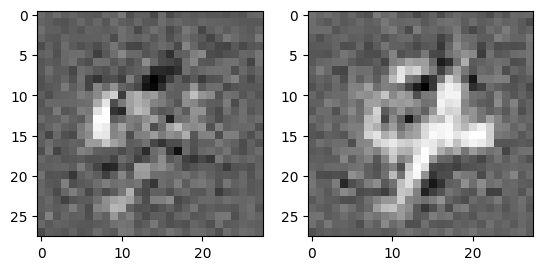

In [29]:
z_opposites = random_sample_z_space(2)
fake_img = generator(z_opposites)

plt.subplot(121); plt.imshow(fake_img[0].squeeze().cpu().detach(), cmap='gray')
plt.subplot(122); plt.imshow(fake_img[1].squeeze().cpu().detach(), cmap='gray')

plt.savefig('./result/GAN/1-GAN/5-side-images.png', dpi=300)

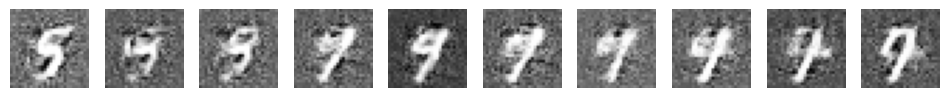

In [38]:
num_interpolation = 10

z_start = z_opposites[0].detach().cpu().numpy()
z_end = z_opposites[1].detach().cpu().numpy()

interp_np = np.linspace(z_start, z_end, num_interpolation)
# z_interpolation = Variable(Tensor(np.linspace(z_opposites[0].cpu(), z_opposites[1].cpu(), num_interpolation)))
z_interpolation = torch.from_numpy(interp_np).float().cuda()
fake_img = generator(z_interpolation)

plt.figure(figsize=(12,2))
for i in range(num_interpolation):
    plt.subplot(1,num_interpolation,i+1)
    plt.imshow(fake_img[i].squeeze().cpu().detach(), cmap='gray')
    plt.axis('off')

plt.savefig('./result/GAN/1-GAN/6-interpolation.png', dpi=300)